# Week 7: Classifiers

This notebook applies classification models to predict emotion from extracted audio features. We compare our MiniLearn implementations against scikit-learn as a reference.

## Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, str(Path.cwd().parent))

from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from minilearn.classifiers.logistic import LogisticRegression as MLLogisticRegression
from sklearn.linear_model import LogisticRegression as SKLogisticRegression
from minilearn.classifiers.decision_tree import DecisionTreeClassifier as MLDecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier as SKDecisionTreeClassifier
from minilearn.classifiers.knn import KNearestNeighbors as MLKNearestNeighbors
from sklearn.neighbors import KNeighborsClassifier as SKKNeighborsClassifier
from minilearn.classifiers.naive_bayes import GaussianNaiveBayes as MLGaussianNaiveBayes
from sklearn.naive_bayes import GaussianNB as SKGaussianNB

## Logistic Regression

In [2]:
# Resolve project root from notebook location
NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / 'SER_Project').exists():
    PROJECT_ROOT = NOTEBOOK_DIR / 'SER_Project'
elif NOTEBOOK_DIR.name == 'notebooks' and (NOTEBOOK_DIR.parent / 'pipeline').exists():
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / 'data'
FEATURES_CSV = DATA_DIR / 'features.csv'

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'FEATURES_CSV exists: {FEATURES_CSV.exists()}')

PROJECT_ROOT: c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project
FEATURES_CSV exists: True


In [3]:
if not FEATURES_CSV.exists():
    raise FileNotFoundError(
        f'Missing {FEATURES_CSV}. Run the feature extraction pipeline first (notebook 01 or CLI).'
    )

df = pd.read_csv(FEATURES_CSV)
print(f'Feature table shape: {df.shape}')
print(f'Emotions: {sorted(df["emotion"].unique())}')
print(f'\nEmotion distribution:\n{df["emotion"].value_counts().sort_index()}')

Feature table shape: (1440, 384)
Emotions: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

Emotion distribution:
emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral       96
sad          192
surprised    192
Name: count, dtype: int64


In [4]:
# Prepare data for classification
target_col = 'emotion'
if target_col not in df.columns:
    raise KeyError(f'Expected target column {target_col} in features.csv')

drop_cols = [
    'filepath', 'filename',
    'modality', 'vocal_channel', 'emotion', 'intensity', 'statement',
    'modality_code', 'vocal_channel_code', 'emotion_code', 'statement_code',
    'intensity_code', 'repetition', 'actor_id',
]

feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f'Features: {X.shape[1]}')
print(f'Rows: {X.shape[0]}')
print(f'Classes: {y.nunique()}')

Features: 370
Rows: 1440
Classes: 8


In [5]:
# Train/test split with stratification to preserve emotion distribution
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values,
    test_size=0.2,
    random_state=42,
    stratify=y.values,
)

# Standardize features (fit on training data only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train_scaled.shape}')
print(f'Test set: {X_test_scaled.shape}')

Training set: (1147, 370)
Test set: (293, 370)


In [6]:
# MiniLearn Logistic Regression
ml_lr = MLLogisticRegression(
    learning_rate=0.01,
    max_iter=500,
    fit_intercept=True,
    l2_penalty=0.0001,
    random_state=42,
    verbose=False,
)
ml_lr.fit(X_train_scaled, y_train)
ml_y_pred = ml_lr.predict(X_test_scaled)

print('MiniLearn LogisticRegression fitted.')
print(f'Accuracy: {ml_lr.score(X_test_scaled, y_test):.4f}')

MiniLearn LogisticRegression fitted.
Accuracy: 0.6314


In [7]:
# Scikit-learn Logistic Regression (for comparison)
sk_lr = SKLogisticRegression(
    max_iter=500,
    penalty='l2',
    C=1e4,  # inverse of l2_penalty
    random_state=42,
    solver='lbfgs',
)
sk_lr.fit(X_train_scaled, y_train)
sk_y_pred = sk_lr.predict(X_test_scaled)

print('Scikit-learn LogisticRegression fitted.')
print(f'Accuracy: {sk_lr.score(X_test_scaled, y_test):.4f}')

Scikit-learn LogisticRegression fitted.
Accuracy: 0.6553


c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [8]:
# Compute metrics for both models
def compute_metrics(y_true, y_pred, model_name):
    """Compute classification metrics."""
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision (macro)': prec_macro,
        'Recall (macro)': recall_macro,
        'F1 (macro)': f1_macro,
    }

metrics_ml = compute_metrics(y_test, ml_y_pred, 'MiniLearn LR')
metrics_sk = compute_metrics(y_test, sk_y_pred, 'Scikit-learn LR')

results_df = pd.DataFrame([metrics_ml, metrics_sk])
print(results_df.to_string(index=False))

          Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
   MiniLearn LR  0.631399           0.633110        0.629487    0.631293
Scikit-learn LR  0.655290           0.648448        0.651923    0.650181


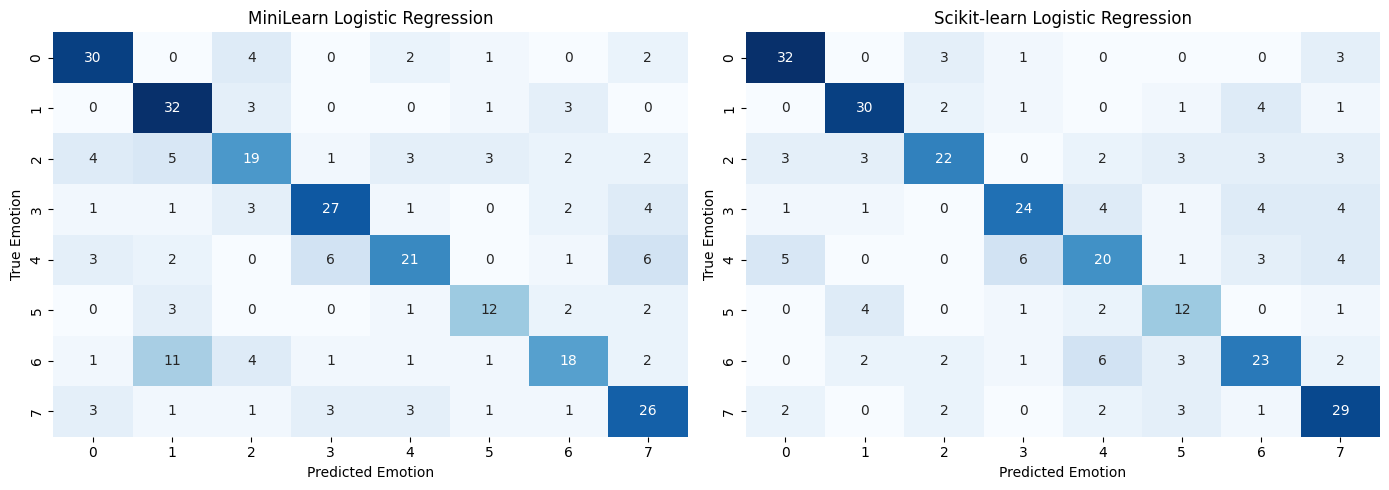

In [9]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_ml = confusion_matrix(y_test, ml_y_pred, labels=np.unique(y_test))
cm_sk = confusion_matrix(y_test, sk_y_pred, labels=np.unique(y_test))

sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('MiniLearn Logistic Regression')
axes[0].set_ylabel('True Emotion')
axes[0].set_xlabel('Predicted Emotion')

sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Scikit-learn Logistic Regression')
axes[1].set_ylabel('True Emotion')
axes[1].set_xlabel('Predicted Emotion')

plt.tight_layout()
plt.show()

## Logistic Regression Summary

Both implementations show similar performance on the SER classification task. The confusion matrices reveal which emotions are confused with one another and can guide feature engineering or model tuning in later weeks.

## Decision Tree

In [10]:
# MiniLearn Decision Tree
ml_dt = MLDecisionTreeClassifier(
    max_depth=6,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
)
ml_dt.fit(X_train, y_train)
ml_dt_y_pred = ml_dt.predict(X_test)

print('MiniLearn DecisionTreeClassifier fitted.')
print(f'Accuracy: {ml_dt.score(X_test, y_test):.4f}')

MiniLearn DecisionTreeClassifier fitted.
Accuracy: 0.3413


In [11]:
# Scikit-learn Decision Tree (for comparison)
sk_dt = SKDecisionTreeClassifier(
    max_depth=6,
    min_samples_split=4,
    min_samples_leaf=2,
    ccp_alpha=0.0,
    random_state=42,
)
sk_dt.fit(X_train, y_train)
sk_dt_y_pred = sk_dt.predict(X_test)

print('Scikit-learn DecisionTreeClassifier fitted.')
print(f'Accuracy: {sk_dt.score(X_test, y_test):.4f}')

Scikit-learn DecisionTreeClassifier fitted.
Accuracy: 0.3515


          Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
   MiniLearn DT  0.341297           0.349829        0.347917    0.348870
Scikit-learn DT  0.351536           0.348944        0.360577    0.354665


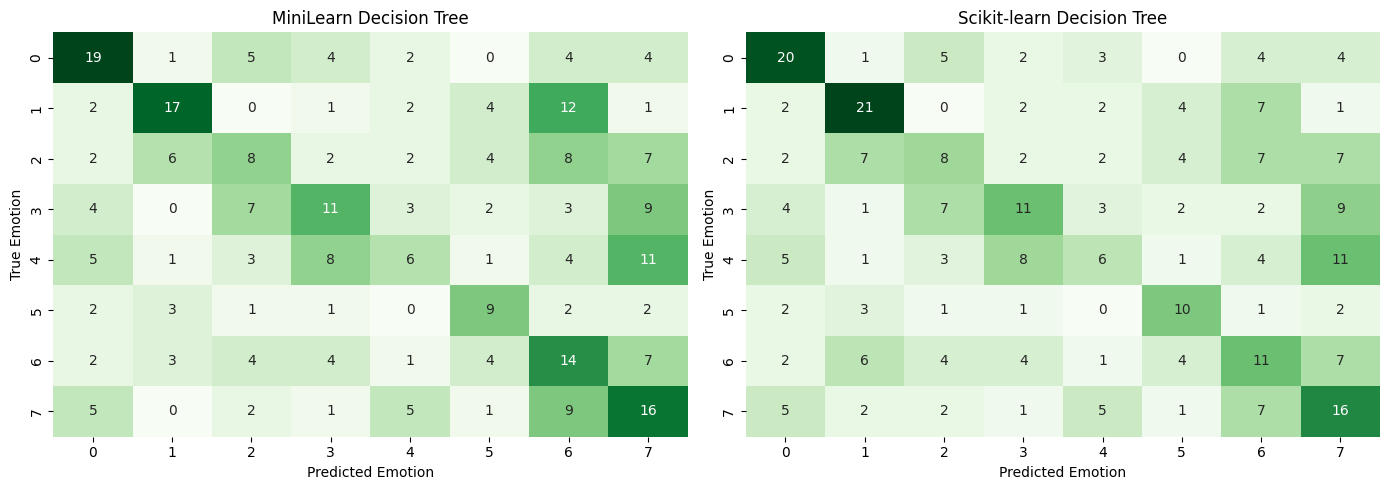

In [12]:
# Decision Tree metrics
metrics_dt_ml = compute_metrics(y_test, ml_dt_y_pred, 'MiniLearn DT')
metrics_dt_sk = compute_metrics(y_test, sk_dt_y_pred, 'Scikit-learn DT')

results_dt_df = pd.DataFrame([metrics_dt_ml, metrics_dt_sk])
print(results_dt_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_dt_ml = confusion_matrix(y_test, ml_dt_y_pred, labels=np.unique(y_test))
cm_dt_sk = confusion_matrix(y_test, sk_dt_y_pred, labels=np.unique(y_test))

sns.heatmap(cm_dt_ml, annot=True, fmt='d', cmap='Greens', ax=axes[0], cbar=False)
axes[0].set_title('MiniLearn Decision Tree')
axes[0].set_ylabel('True Emotion')
axes[0].set_xlabel('Predicted Emotion')

sns.heatmap(cm_dt_sk, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Scikit-learn Decision Tree')
axes[1].set_ylabel('True Emotion')
axes[1].set_xlabel('Predicted Emotion')

plt.tight_layout()
plt.show()

## Decision Tree Summary

MiniLearn and scikit-learn decision trees are compared above. The scikit-learn model is constructed with `ccp_alpha=0.0` (no post-pruning). Increasing `ccp_alpha` will prune the tree and can help reduce overfitting; try values such as 0.001 or 0.01 and re-evaluate.

Use the printed metrics and confusion matrices to compare Accuracy, Precision, Recall, and F1 for each implementation. The MiniLearn tree is a lightweight reference implementation; use scikit-learn's implementation and `ccp_alpha` tuning for production experiments or further hyperparameter search.

## k-Nearest Neighbors

In [13]:
# Hyperparameter for k-Nearest Neighbors
n_neighbors = 5

In [14]:
# MiniLearn k-Nearest Neighbors
ml_knn = MLKNearestNeighbors(n_neighbors=n_neighbors, weights='uniform')
ml_knn.fit(X_train, y_train)
ml_knn_y_pred = ml_knn.predict(X_test)

print('MiniLearn KNearestNeighbors fitted.')
print(f'Accuracy: {ml_knn.score(X_test, y_test):.4f}')

MiniLearn KNearestNeighbors fitted.
Accuracy: 0.2560


In [15]:
# Scikit-learn k-Nearest Neighbors (for comparison)
sk_knn = SKKNeighborsClassifier(n_neighbors=n_neighbors, weights='uniform')
sk_knn.fit(X_train, y_train)
sk_knn_y_pred = sk_knn.predict(X_test)

print('Scikit-learn KNeighborsClassifier fitted.')
print(f'Accuracy: {sk_knn.score(X_test, y_test):.4f}')

Scikit-learn KNeighborsClassifier fitted.
Accuracy: 0.2526


           Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
   MiniLearn KNN  0.255973           0.252327        0.246474    0.249366
Scikit-learn KNN  0.252560           0.237617        0.240224    0.238914


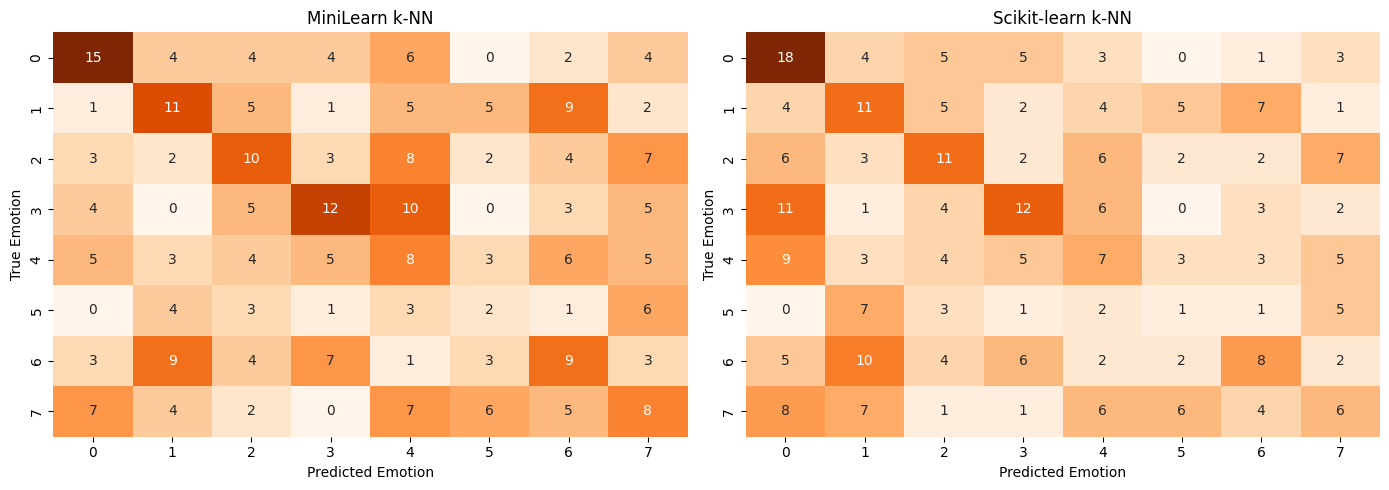

In [16]:
# k-NN metrics
metrics_knn_ml = compute_metrics(y_test, ml_knn_y_pred, 'MiniLearn KNN')
metrics_knn_sk = compute_metrics(y_test, sk_knn_y_pred, 'Scikit-learn KNN')

results_knn_df = pd.DataFrame([metrics_knn_ml, metrics_knn_sk])
print(results_knn_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_knn_ml = confusion_matrix(y_test, ml_knn_y_pred, labels=np.unique(y_test))
cm_knn_sk = confusion_matrix(y_test, sk_knn_y_pred, labels=np.unique(y_test))

sns.heatmap(cm_knn_ml, annot=True, fmt='d', cmap='Oranges', ax=axes[0], cbar=False)
axes[0].set_title('MiniLearn k-NN')
axes[0].set_ylabel('True Emotion')
axes[0].set_xlabel('Predicted Emotion')

sns.heatmap(cm_knn_sk, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('Scikit-learn k-NN')
axes[1].set_ylabel('True Emotion')
axes[1].set_xlabel('Predicted Emotion')

plt.tight_layout()
plt.show()

## k-Nearest Neighbors Summary

MiniLearn and scikit-learn k-NN implementations are compared above. The models use `n_neighbors=5` with uniform weighting. Adjust `n_neighbors` to explore the bias-variance tradeoff: smaller k leads to lower bias but higher variance, while larger k smooths predictions.

The metrics and confusion matrices show how k-NN performance compares to Logistic Regression and Decision Trees. k-NN is a non-parametric model that can capture local patterns but may be slower on large datasets due to distance computations at prediction time.

## Naive Bayes

In [17]:
# Hyperparameter for Gaussian Naive Bayes
var_smoothing = 1e-9

In [18]:
# MiniLearn Gaussian Naive Bayes
ml_gnb = MLGaussianNaiveBayes(var_smoothing=var_smoothing)
ml_gnb.fit(X_train, y_train)
ml_gnb_y_pred = ml_gnb.predict(X_test)

print('MiniLearn Gaussian Naive Bayes fitted.')
print(f'Accuracy: {ml_gnb.score(X_test, y_test):.4f}')

MiniLearn Gaussian Naive Bayes fitted.
Accuracy: 0.3447


In [19]:
# Scikit-learn Gaussian Naive Bayes (for comparison)
sk_gnb = SKGaussianNB(var_smoothing=var_smoothing)
sk_gnb.fit(X_train, y_train)
sk_gnb_y_pred = sk_gnb.predict(X_test)

print('Scikit-learn Gaussian Naive Bayes fitted.')
print(f'Accuracy: {sk_gnb.score(X_test, y_test):.4f}')

Scikit-learn Gaussian Naive Bayes fitted.
Accuracy: 0.3447


           Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
   MiniLearn GNB   0.34471           0.372482        0.363301    0.367834
Scikit-learn GNB   0.34471           0.381797        0.363301    0.372320


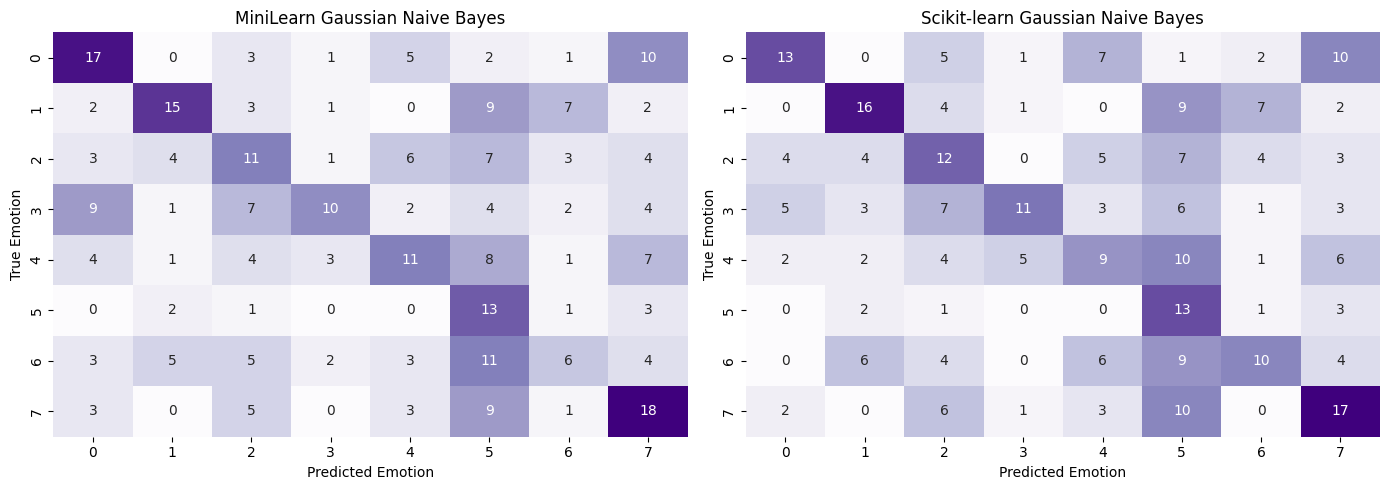

In [20]:
# Gaussian Naive Bayes metrics
metrics_gnb_ml = compute_metrics(y_test, ml_gnb_y_pred, 'MiniLearn GNB')
metrics_gnb_sk = compute_metrics(y_test, sk_gnb_y_pred, 'Scikit-learn GNB')

results_gnb_df = pd.DataFrame([metrics_gnb_ml, metrics_gnb_sk])
print(results_gnb_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_gnb_ml = confusion_matrix(y_test, ml_gnb_y_pred, labels=np.unique(y_test))
cm_gnb_sk = confusion_matrix(y_test, sk_gnb_y_pred, labels=np.unique(y_test))

sns.heatmap(cm_gnb_ml, annot=True, fmt='d', cmap='Purples', ax=axes[0], cbar=False)
axes[0].set_title('MiniLearn Gaussian Naive Bayes')
axes[0].set_ylabel('True Emotion')
axes[0].set_xlabel('Predicted Emotion')

sns.heatmap(cm_gnb_sk, annot=True, fmt='d', cmap='Purples', ax=axes[1], cbar=False)
axes[1].set_title('Scikit-learn Gaussian Naive Bayes')
axes[1].set_ylabel('True Emotion')
axes[1].set_xlabel('Predicted Emotion')

plt.tight_layout()
plt.show()

## Naive Bayes Summary

MiniLearn and scikit-learn Gaussian Naive Bayes implementations are compared above. Gaussian Naive Bayes assumes each feature is normally distributed within each class, making it a probabilistic model suitable for emotion recognition where feature distributions may differ by emotion.

The `var_smoothing` parameter prevents numerical issues with very small variances.